In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'features.csv'))

drop_cols = ['EventID', 'GaugeID', 'Start Date', 'End Date',
             'Peak FL Date', 'Flood Type', 'Peak Discharge Date',
             'Station', 'River Name/ Tributory/ SubTributory',
             'Basin', 'Privacy', 'Reliability',
             'KoppenGeiger Climate Type', 'Land cover',
             'Soil type', 'lithology type', 'State']

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# drop any remaining non-numeric columns
obj_cols = df_model.select_dtypes(include=['object', 'datetime64']).columns.tolist()
print("Dropping non-numeric columns:", obj_cols)
df_model = df_model.drop(columns=obj_cols)

X = df_model.drop(columns=['label'])
y = df_model['label']

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Dropping non-numeric columns: ['Start_date', 'End_date']
Features: 121, Samples: 4548


C:\Users\USER\AppData\Local\Temp\ipykernel_10444\3066859717.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df_model.select_dtypes(include=['object', 'datetime64']).columns.tolist()


In [3]:
# split by year — not random — to avoid temporal leakage
# train on events before 2018, test on 2018 onwards
train_mask = df['year'] < 2018

X_train = X[train_mask]
X_test  = X[~train_mask]
y_train = y[train_mask]
y_test  = y[~train_mask]

print(f"Train: {X_train.shape[0]} events, Test: {X_test.shape[0]} events")
print(f"Train label dist:\n{y_train.value_counts()}")
print(f"Test label dist:\n{y_test.value_counts()}")

Train: 4130 events, Test: 418 events
Train label dist:
label
0    2738
1    1392
Name: count, dtype: int64
Test label dist:
label
1    237
0    181
Name: count, dtype: int64


In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
        random_state=42, n_jobs=-1, eval_metric='logloss')
}

# logistic regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    preds  = model.predict(X_te)
    probs  = model.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_test, probs)
    results[name] = {'model': model, 'preds': preds, 'probs': probs, 'auc': auc}
    print(f"\n{name} — AUC: {auc:.3f}")
    print(classification_report(y_test, preds, target_names=['Flood', 'Severe']))


Logistic Regression — AUC: 0.521
              precision    recall  f1-score   support

       Flood       0.44      0.58      0.50       181
      Severe       0.58      0.44      0.50       237

    accuracy                           0.50       418
   macro avg       0.51      0.51      0.50       418
weighted avg       0.52      0.50      0.50       418


Random Forest — AUC: 0.789
              precision    recall  f1-score   support

       Flood       0.53      0.92      0.68       181
      Severe       0.87      0.38      0.53       237

    accuracy                           0.62       418
   macro avg       0.70      0.65      0.60       418
weighted avg       0.72      0.62      0.59       418


XGBoost — AUC: 0.793
              precision    recall  f1-score   support

       Flood       0.63      0.77      0.69       181
      Severe       0.79      0.65      0.72       237

    accuracy                           0.71       418
   macro avg       0.71      0.71      0.71 

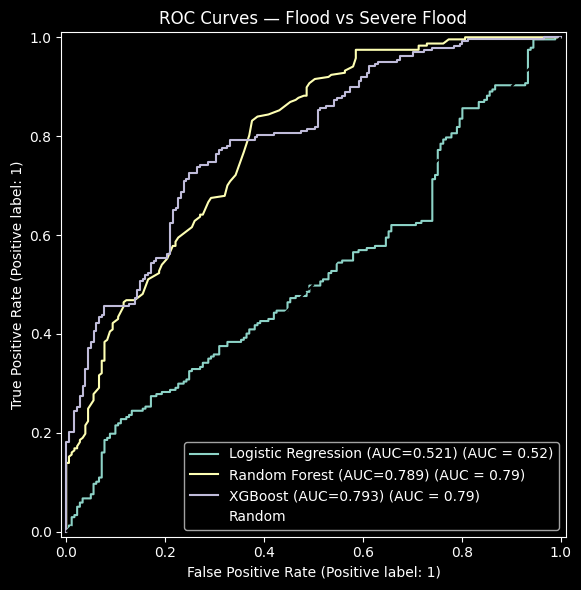

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['probs'], name=f"{name} (AUC={res['auc']:.3f})", ax=ax)

ax.plot([0,1], [0,1], 'k--', label='Random')
ax.set_title('ROC Curves — Flood vs Severe Flood')
ax.legend(loc='lower right')
plt.tight_layout()

os.makedirs(os.path.join('..', 'outputs', 'figures'), exist_ok=True)
plt.savefig(os.path.join('..', 'outputs', 'figures', 'roc_curves.png'), dpi=150)
plt.show()

In [6]:
import joblib

os.makedirs(os.path.join('..', 'models'), exist_ok=True)

# save XGBoost as best model
joblib.dump(results['XGBoost']['model'],
            os.path.join('..', 'models', 'xgb_best.pkl'))

# save scaler for logistic regression (needed if deploying later)
joblib.dump(scaler, os.path.join('..', 'models', 'scaler.pkl'))

print("Models saved.")

Models saved.
